# Sparse and Noisy Sensor Data from the Thermal System

This notebook converts the validated numerical heat-diffusion model into a sparse sensor-monitoring problem.

In the previous notebook, the numerical solver provided the complete temperature field:

$$
T(x,t)
$$

at every simulated position and time.

In a real physical system, however, the complete temperature field is usually not directly observable. Instead, only a limited number of sensors may be available.

The objectives of this notebook are to:

- generate a high-resolution reference temperature field
- place a small number of virtual temperature sensors along the rod
- extract temperature measurements from those sensor locations
- introduce realistic measurement noise
- compare sparse measurements with the complete physical temperature field
- prepare a dataset for later machine-learning and Physics-Informed Neural Network experiments

The numerical solution will be treated as the underlying physical ground truth.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. From a Temperature Field to Sensor Measurements

The numerical heat solver provides the temperature:

$$
T(x,t)
$$

across the complete rod.

A physical monitoring system would instead measure temperature only at selected sensor positions:

$$
x_1,\ x_2,\ \ldots,\ x_m
$$

For example, with five sensors we may observe:

$$
T(x_1,t),\quad
T(x_2,t),\quad
T(x_3,t),\quad
T(x_4,t),\quad
T(x_5,t)
$$

while the temperatures between those sensor locations remain unobserved.

This creates a sparse-data problem.

Later, the objective of the machine-learning model will be to reconstruct or predict information about the full physical system using only limited measurements.

## 2. Generating the Reference Temperature Field

The validated FTCS solver is used to generate the complete temperature evolution of the rod.

For this stage, the numerical simulation represents the underlying physical system.

The complete solution will be retained as reference data, while the virtual sensors will observe only a small subset of the spatial locations.

In [2]:
def simulate_heat_field(
    nx=81,
    t_final=200.0,
    alpha=1.0e-4,
    r_target=0.45
):

    # Physical domain
    L = 1.0
    x = np.linspace(0, L, nx)
    dx = x[1] - x[0]

    # Stable time step
    dt_target = r_target * dx**2 / alpha

    n_steps = int(np.ceil(t_final / dt_target))

    dt = t_final / n_steps

    r = alpha * dt / dx**2

    # Initial temperature distribution
    T_ambient = 20.0
    A = 80.0
    x_center = 0.5
    sigma = 0.08

    T = T_ambient + A * np.exp(
        -((x - x_center)**2) / (2 * sigma**2)
    )

    # Fixed-temperature boundaries
    T[0] = T_ambient
    T[-1] = T_ambient

    # Store initial condition
    history = [T.copy()]

    # Time integration
    for n in range(n_steps):

        T_new = T.copy()

        for i in range(1, nx - 1):

            T_new[i] = (
                T[i]
                + r * (
                    T[i + 1]
                    - 2 * T[i]
                    + T[i - 1]
                )
            )

        T_new[0] = T_ambient
        T_new[-1] = T_ambient

        T = T_new

        history.append(T.copy())

    history = np.array(history)

    time = np.arange(len(history)) * dt

    return x, time, history, dx, dt, r

In [3]:
x, time, temperature_field, dx, dt, r = simulate_heat_field()

print("Temperature-field shape:", temperature_field.shape)
print("Number of spatial points:", len(x))
print("Number of time points:", len(time))
print("dx:", dx, "m")
print("dt:", dt, "s")
print("r:", r)

Temperature-field shape: (286, 81)
Number of spatial points: 81
Number of time points: 286
dx: 0.0125 m
dt: 0.7017543859649122 s
r: 0.44912280701754376


## 3. Virtual Temperature Sensors

Five virtual temperature sensors are positioned along the rod at:

$$
x =
0.20,\ 0.35,\ 0.50,\ 0.65,\ 0.80
\text{ m}
$$

The sensor at $x=0.50$ m is located at the center of the initial hot region.

The remaining sensors monitor how the thermal disturbance propagates away from the center.

Only temperatures at these locations will be treated as observed measurements.

In [4]:
sensor_positions = np.array([
    0.20,
    0.35,
    0.50,
    0.65,
    0.80
])

print(sensor_positions)

[0.2  0.35 0.5  0.65 0.8 ]


In [5]:
sensor_indices = []

for position in sensor_positions:

    index = np.argmin(
        np.abs(x - position)
    )

    sensor_indices.append(index)

sensor_indices = np.array(sensor_indices)

print("Sensor indices:", sensor_indices)
print("Actual grid positions:", x[sensor_indices])

Sensor indices: [16 28 40 52 64]
Actual grid positions: [0.2  0.35 0.5  0.65 0.8 ]


In [6]:
sensor_data = temperature_field[:, sensor_indices]

print("Sensor data shape:", sensor_data.shape)

Sensor data shape: (286, 5)


In [7]:
sensor_df = pd.DataFrame(
    sensor_data,
    columns=[
        "sensor_0.20m",
        "sensor_0.35m",
        "sensor_0.50m",
        "sensor_0.65m",
        "sensor_0.80m"
    ]
)

sensor_df.insert(0, "time_s", time)

sensor_df.head()

,time_s,sensor_0.20m,sensor_0.35m,sensor_0.50m,sensor_0.65m,sensor_0.80m
0,0.000000,20.070706,33.793730,100.000000,33.793730,20.070706
1,0.701754,20.081017,34.172447,99.128139,34.172447,20.081017
2,1.403509,20.092333,34.541664,98.284554,34.541664,20.092333
3,2.105263,20.104691,34.901423,97.467728,34.901423,20.104691
4,2.807018,20.118127,35.251791,96.676258,35.251791,20.118127


## 4. Adding Measurement Noise

The numerical solver produces exact temperature values for the simulated system.

Real sensors, however, are affected by measurement noise due to factors such as sensor accuracy, electronics, calibration, and environmental disturbances.

To imitate this behavior, Gaussian noise is added to the virtual sensor measurements.

The noisy measurement can be represented as:

$$
T_{\text{measured}}
=
T_{\text{true}}
+
\epsilon
$$

where:

$$
\epsilon \sim \mathcal{N}(0,\sigma_{\text{noise}}^2)
$$

Here, $\sigma_{\text{noise}}$ controls the magnitude of the sensor noise.

The original simulated temperatures are kept as the ground-truth values for later comparison.

In [8]:
np.random.seed(42)

noise_std = 0.5

noise = np.random.normal(
    loc=0.0,
    scale=noise_std,
    size=sensor_data.shape
)

sensor_data_noisy = sensor_data + noise

In [9]:
noisy_sensor_df = pd.DataFrame(
    sensor_data_noisy,
    columns=[
        "sensor_0.20m",
        "sensor_0.35m",
        "sensor_0.50m",
        "sensor_0.65m",
        "sensor_0.80m"
    ]
)

noisy_sensor_df.insert(0, "time_s", time)

noisy_sensor_df.head()

,time_s,sensor_0.20m,sensor_0.35m,sensor_0.50m,sensor_0.65m,sensor_0.80m
0,0.000000,20.319063,33.724598,100.323844,34.555245,19.953629
1,0.701754,19.963949,34.962053,99.511857,33.937709,20.352297
2,1.403509,19.860624,34.308799,98.405535,33.585024,19.229874
3,2.105263,19.823547,34.395007,97.624852,34.447411,19.398539
4,2.807018,20.850951,35.138902,96.710022,34.539417,19.845936


## 5. Comparing True and Noisy Sensor Measurements

The numerical simulation provides the underlying true temperature signal, while the noisy sensor data represent the measurements that would be observed in practice.

Comparing the two signals illustrates how measurement noise affects the observed temperature without changing the underlying physical behavior.

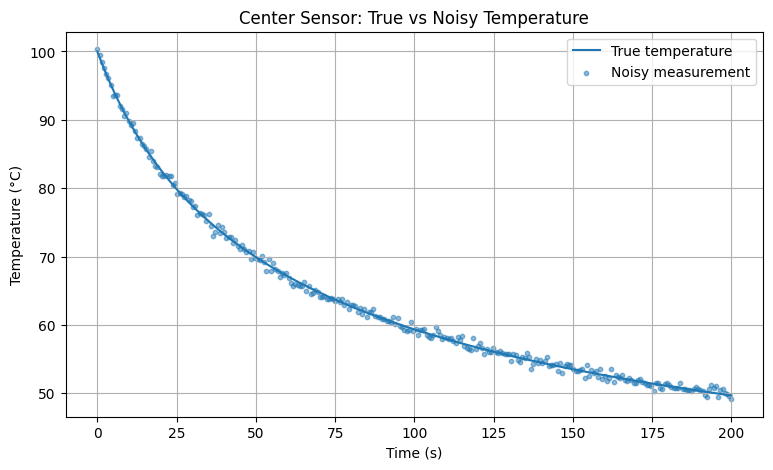

In [10]:
sensor_id = 2

plt.figure(figsize=(9, 5))

plt.plot(
    time,
    sensor_data[:, sensor_id],
    label="True temperature"
)

plt.scatter(
    time,
    sensor_data_noisy[:, sensor_id],
    s=10,
    alpha=0.5,
    label="Noisy measurement"
)

plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")
plt.title("Center Sensor: True vs Noisy Temperature")
plt.legend()
plt.grid()

plt.show()

## 6. Measurement Residuals

The difference between the noisy sensor measurement and the underlying true temperature is called the measurement residual:

$$
e(t)
=
T_{\text{measured}}(t)
-
T_{\text{true}}(t)
$$

Because the synthetic noise was generated from a zero-mean Gaussian distribution, the residuals should have a mean close to:

$$
0
$$

and a standard deviation close to the chosen sensor noise level:

$$
\sigma_{\text{noise}} = 0.5^\circ C
$$

Analyzing the residuals verifies that the simulated sensor noise behaves as intended.

In [11]:
residuals = sensor_data_noisy - sensor_data

print("Residual mean:", residuals.mean())
print("Residual standard deviation:", residuals.std())

Residual mean: 0.01862768268448062
Residual standard deviation: 0.4943211414693778


In [12]:
center_residuals = residuals[:, 2]

print("Center sensor residual mean:", center_residuals.mean())
print("Center sensor residual std:", center_residuals.std())

Center sensor residual mean: 0.013697540978270745
Center sensor residual std: 0.47977379303529777


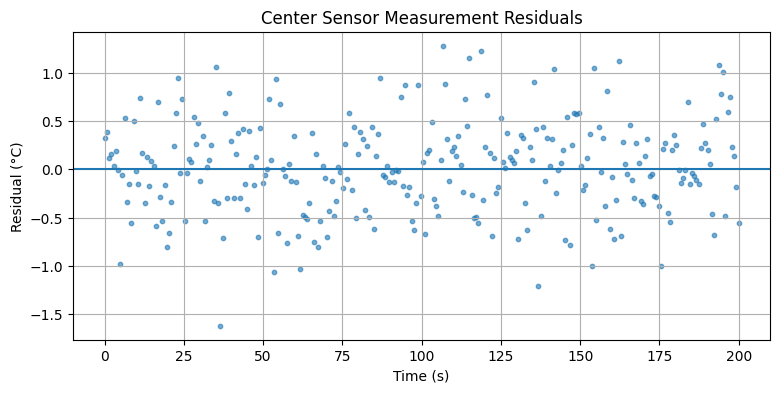

In [13]:
plt.figure(figsize=(9, 4))

plt.scatter(
    time,
    center_residuals,
    s=10,
    alpha=0.6
)

plt.axhline(0)

plt.xlabel("Time (s)")
plt.ylabel("Residual (°C)")
plt.title("Center Sensor Measurement Residuals")

plt.grid()
plt.show()

## 7. Simulating Missing Sensor Measurements

Real sensor systems do not always provide measurements at every expected time step.

Measurements may be missing because of communication loss, temporary sensor failure, data acquisition problems, or other operational issues.

To represent this behavior, a small percentage of the noisy sensor measurements will be removed randomly.

Missing values will be represented using:

$$
\text{NaN}
$$

The underlying numerical temperature field remains available as ground truth, but the observed sensor dataset becomes incomplete.

In [14]:
np.random.seed(42)

missing_rate = 0.05

missing_mask = np.random.random(
    sensor_data_noisy.shape
) < missing_rate

In [15]:
sensor_data_missing = sensor_data_noisy.copy()

sensor_data_missing[missing_mask] = np.nan

In [16]:
print("Total measurements:", sensor_data_missing.size)

print(
    "Missing measurements:",
    np.isnan(sensor_data_missing).sum()
)

print(
    "Actual missing percentage:",
    np.isnan(sensor_data_missing).mean() * 100
)

Total measurements: 1430
Missing measurements: 79
Actual missing percentage: 5.524475524475524


In [17]:
missing_sensor_df = pd.DataFrame(
    sensor_data_missing,
    columns=[
        "sensor_0.20m",
        "sensor_0.35m",
        "sensor_0.50m",
        "sensor_0.65m",
        "sensor_0.80m"
    ]
)

missing_sensor_df.insert(0, "time_s", time)

missing_sensor_df.head(10)

,time_s,sensor_0.20m,sensor_0.35m,sensor_0.50m,sensor_0.65m,sensor_0.80m
0,0.000000,20.319063,33.724598,100.323844,34.555245,19.953629
1,0.701754,19.963949,34.962053,99.511857,33.937709,20.352297
2,1.403509,NaN,34.308799,98.405535,33.585024,19.229874
3,2.105263,19.823547,34.395007,97.624852,34.447411,19.398539
4,2.807018,20.850951,35.138902,96.710022,34.539417,19.845936
5,3.508772,20.188134,35.017364,96.096693,35.292541,NaN
6,4.210526,19.847504,36.850884,95.157527,35.395889,20.559630
7,4.912281,19.554784,36.352006,93.461596,35.583481,20.263636
8,5.614035,20.552473,36.647175,NaN,36.410939,19.443978
9,6.315789,19.842554,36.636332,93.585351,37.038460,19.320956


## 8. Visualizing Sensor Dropout

The incomplete sensor data are compared with the underlying true temperature signal.

Missing observations create gaps in the measured time series while the physical temperature field continues to evolve continuously.

This illustrates the difference between the true physical state of the system and the limited information available from the monitoring sensors.

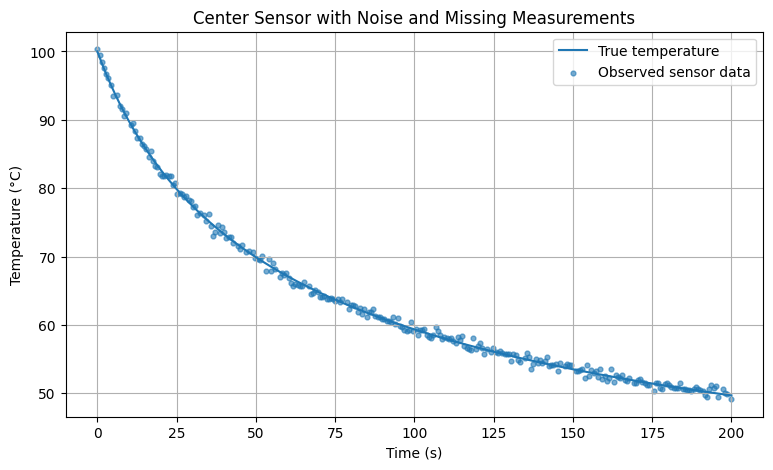

In [18]:
sensor_id = 2

plt.figure(figsize=(9, 5))

plt.plot(
    time,
    sensor_data[:, sensor_id],
    label="True temperature"
)

plt.scatter(
    time,
    sensor_data_missing[:, sensor_id],
    s=12,
    alpha=0.6,
    label="Observed sensor data"
)

plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")
plt.title("Center Sensor with Noise and Missing Measurements")

plt.legend()
plt.grid()
plt.show()

## 9. Sensor Data Summary

The validated numerical heat solver was used as the underlying physical ground truth.

Five virtual temperature sensors were placed along the rod. Gaussian measurement noise with a standard deviation of approximately $0.5^\circ C$ was added to simulate imperfect sensor measurements.

A fraction of the measurements was then removed to represent sensor dropout and incomplete observations.

The resulting dataset therefore contains:

- sparse spatial measurements
- measurement noise
- missing observations
- access to the complete numerical temperature field for validation

This creates the observation problem that will be used in the following notebooks to compare data-driven and physics-informed machine-learning approaches.

In [21]:
missing_sensor_df.to_csv(
    "../data/thermal_sensor_data.csv",
    index=False
)

In [22]:
np.savez(
    "../data/reference_temperature_field.npz",
    x=x,
    time=time,
    temperature_field=temperature_field
)